In [ ]:
%load_ext autoreload
%autoreload 2
# Always Restart Kernel after modifying backend file
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from backend_aipw import *
from joblib import Parallel, delayed
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from scipy.special import logit, expit
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR

In [ ]:
def generate_dgp3_params(rng, n, dim_factor, spars_factor=None, fixed_s=None): # Takes as input the sample size, dimensionality factor, and sparsity factor
    # Hyperparameters controlling the strength of confounding and noise
    p_band = [0.2, 0.8]
    beta_strength = 2.5 # Before 3.0
    rho_strength = 0.8 # Before 1.2
    beta_noise = 0.5
    rho_noise = 0.3
    
    # Set Dimensionality
    n_groups = int(dim_factor * n)  # Dimensionality: grows with n
    
    # Set Sparsity
    if fixed_s is not None:
        nunique = fixed_s # Fixed Sparsity -> independent of n
    else:
        nunique = int(spars_factor * n_groups) # Relative Sparsity -> varies with n
    
    s_unique = rng.normal(0, 1, nunique) # Direct Supervisor Translation of latent factor
    s = np.resize(s_unique, n_groups) # Direct Supervisor Translation of latent factor
    #s += 0.01 * rng.normal(0, 1, size=n_groups) # Add small noise to break perfect repetition
    
    # INCORRECT APPROACH: causes SVD convergence failure [Latent sparsity]
    #s = np.zeros(n_groups)
    #active_idx = rng.choice(n_groups, size=nunique, replace=False) # Controlling which groups are assigned signal. Rest of Groups have zero signal
    #s[active_idx] = rng.normal(0, 1, size=nunique)

    # Baseline outcomes (beta_g) are driven by latent 's'
    beta_g = beta_strength * s + beta_noise * rng.normal(0, 1, size=n_groups)
    # Propensity latent score (rho_latent) is ALSO driven by 's' -> Strong Confounding!
    rho_latent = rho_strength * s + rho_noise * rng.normal(0, 1, size=n_groups)

    # Bound Propensities cleanly strictly within p_band
    a = logit(p_band[0])
    b = logit(p_band[1])
    rho_g = np.clip(rho_latent, a, b)
    p_g = expit(rho_g) # convert back to probabilities

    return n_groups, beta_g, p_g

In [ ]:
# --- New Supervisor-Inspired DGP 3 ---
def dgp3_supervisor(rng, n, n_groups, beta_g, p_g):
    """
    High-dimensional, strongly confounded DGP based on supervisor's R code.
    Breaks AIPW by combining sparsity with extreme correlation between 
    outcomes and propensity scores.
    """
    # Generate the Sample
    gid = rng.integers(0, n_groups, size=n)
    
    # One-hot encoding matrix [Structural sparsity]
    X = np.zeros((n, n_groups))
    X[np.arange(n), gid] = 1.0

    # Map group parameters to individuals
    mu0 = beta_g[gid]
    mu1 = mu0 + 1.0  # Constant treatment effect tau = 1.0
    p = p_g[gid]

    # Assign treatment based on confounded propensity
    D = rng.binomial(1, p)

    # Generate Final Outcomes
    sigma_y = 1.0
    Y0 = mu0 + rng.normal(0, sigma_y, size=n)
    Y1 = mu1 + rng.normal(0, sigma_y, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [ ]:
"""
Plan - Machine Learners to be implemented
1) Fused Lasso
2) Conditional Inference Forest
3) Logit Lasso
4) Neural Nets
5) Boosted Trees
"""
"""
Types of Learers:
1) Linear Learners: OLS, Ridge, Lasso, Elastic Net
2) Tree-based Learners: Random Forest, Gradient Boosting, CatBoost, XG
3) Kernel-based Learners: Kernel Ridge Regression, Support Vector Regression
"""

learners_regime = {
    # Worst Estimator to Best Estimator
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0), # Ridge with default parameters (alpha=1.0)
    "Lasso": Lasso(alpha=1.0, max_iter=10000), # Lasso with default parameters (alpha=1.0)
    "ElasticNet": ElasticNet(max_iter=10000), # Elastic Net
    "RF": RandomForestRegressor(n_estimators=300, random_state=123, n_jobs=1), # Random Forest
    "GB": GradientBoostingRegressor(n_estimators=300, random_state=123), # Gradient Boosting
    "CatBoost": CatBoostRegressor(verbose=0, random_state=123, iterations=300, thread_count=1), # CatBoost
    "XGBoost": XGBRegressor(n_estimators=300, random_state=123, n_jobs=1), # XGBoost
    "KRR_RBF": KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1), # Kernel Ridge Regression
    "SVR_RBF": SVR(kernel='rbf', C=1.0, epsilon=0.1), # # Support Vector Regression
}

In [ ]:
# DGP 3
# MC Parameters 
n = 100 # Sample size
dim_factor = 0.4 # Dimensionality factor: when dim_factor > 1.0 the number of groups exceeds the sample size, creating a high-dimensional setting 
#spars_factor = 0.5 # Sparsity factor: when spars_factor = 1.0, there is no sparsity
constant_fixed_sparsity = 10

print("DGP 3")
print("Sample Size", n)
print("Dimensionality", dim_factor)
print("Constant Fixed Sparsity", constant_fixed_sparsity)
n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=dim_factor, spars_factor=None, fixed_s = constant_fixed_sparsity)
tuned_learners_3 = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
print(monte_carlo_parallel(dgp3_supervisor, tuned_learners_3, n=n, sims=100, n_groups=n_groups, beta_g=beta_g, p_g=p_g))

Running simulation for dim_factor=0.1...
Running simulation for dim_factor=0.2...
Running simulation for dim_factor=0.4...
Running simulation for dim_factor=0.6...
Running simulation for dim_factor=0.8...
Running simulation for dim_factor=1.0...
Running simulation for dim_factor=1.2...
Running simulation for dim_factor=1.4...
Running simulation for dim_factor=1.6...
Running simulation for dim_factor=1.8...
Running simulation for dim_factor=2.0...


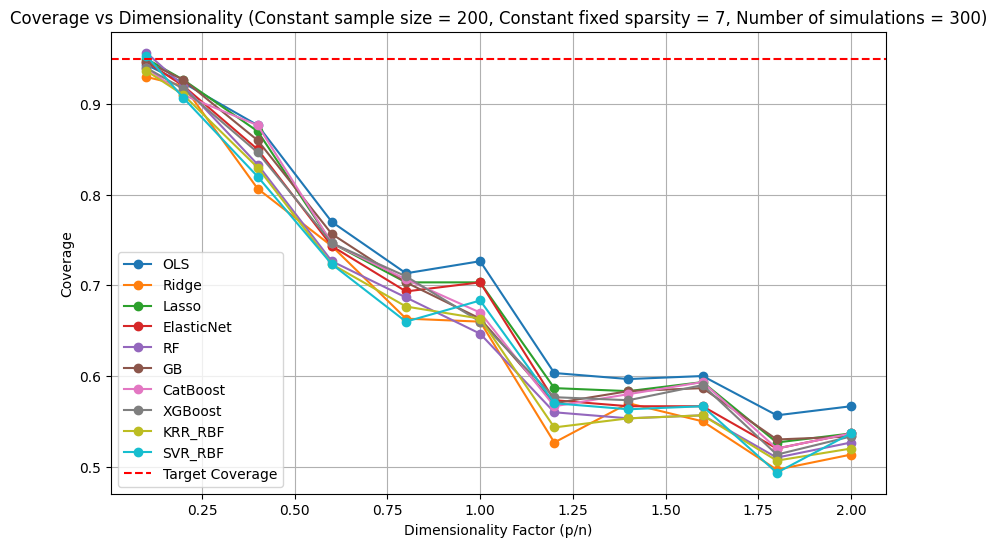

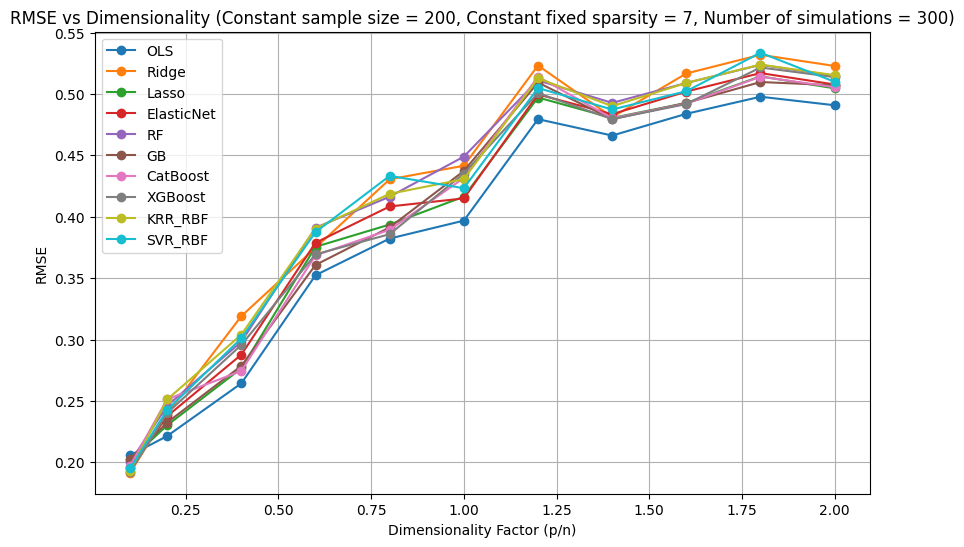

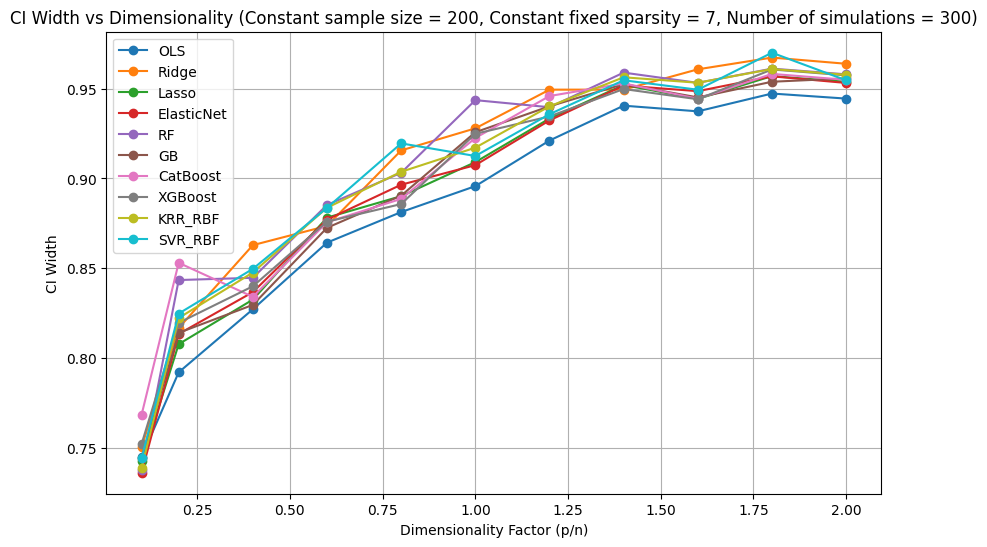

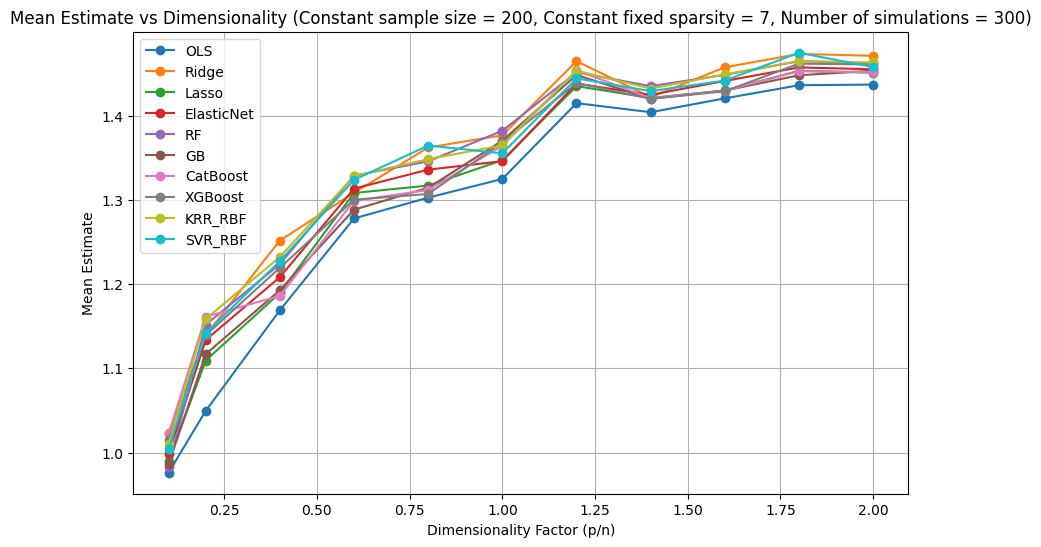

In [ ]:
# ANALYSIS - Dimensionality (1) [Constant sample size, Constant fixed sparsity]
dimensionality_sizes = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]  # Factors of n to determine number of groups
fixed_sample_size = 200
constant_fixed_sparsity = 7 # unique groups
simulations = 300
results_n = []

for dim in dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=dim, spars_factor=None, fixed_s=constant_fixed_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['dim_factor'] = dim
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures 
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))
fig_mean, ax_mean = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("dim_factor")
    x = subset['dim_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)
    ax_mean.plot(x, subset['Mean'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Dimensionality Factor (p/n)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Dimensionality Factor (p/n)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Dimensionality Factor (p/n)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

# Mean formatting
ax_mean.set_title(f"Mean Estimate vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_mean.set_xlabel("Dimensionality Factor (p/n)")
ax_mean.set_ylabel("Mean Estimate")
ax_mean.grid(True)
ax_mean.legend()

plt.show()

In [ ]:
# ANALYSIS - Dimensionality (2) [Constant sample size, Constant relative sparsity]
dimensionality_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
fixed_sample_size = 200
constant_relative_sparsity = 0.5
simulations = 300
results_n = []

for dim in dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=dim, spars_factor=constant_relative_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['dim_factor'] = dim
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures 
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))
fig_mean, ax_mean = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("dim_factor")
    x = subset['dim_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)
    ax_mean.plot(x, subset['Mean'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Dimensionality Factor (p/n)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Dimensionality Factor (p/n)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Dimensionality Factor (p/n)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

# Mean formatting
ax_mean.set_title(f"Mean Estimate vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_mean.set_xlabel("Dimensionality Factor (p/n)")
ax_mean.set_ylabel("Mean Estimate")
ax_mean.grid(True)
ax_mean.legend()

plt.show()

In [ ]:
# ANALYSIS - Sparsity
sparsity_sizes = [0.2, 0.4, 0.6, 0.8, 1.0] # Relative Sparsity factors to determine number of unique signals
fixed_sample_size = 200
fixed_dimensionality_size = 1.0 # 0.8 was too high
simulations = 300
results_n = []

for spars in sparsity_sizes:
    print(f"Running simulation for spars_factor={spars}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=fixed_dimensionality_size, spars_factor=spars) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['spars_factor'] = spars
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))
fig_mean, ax_mean = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("spars_factor")
    x = subset['spars_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)
    ax_mean.plot(x, subset['Mean'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Sparsity Factor (s/p)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Sparsity Factor (s/p)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Sparsity Factor (s/p)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

# Mean formatting
ax_mean.set_title(f"Mean Estimate vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_mean.set_xlabel("Sparsity Factor (s/p)")
ax_mean.set_ylabel("Mean Estimate")
ax_mean.grid(True)
ax_mean.legend()

plt.show()

In [ ]:
# ANALYSIS - Sample Size
sample_sizes = [50, 100, 200, 400, 800] # Sample sizes to test
fixed_dimensionality_size = 1.0 # 0.8 was too high
fixed_sparsity_size = 0.5
simulations = 300
results_n = []

for n in sample_sizes:
    print(f"Running simulation for sample_size={n}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=fixed_dimensionality_size, spars_factor=fixed_sparsity_size) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=n, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['sample_size'] = n
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))
fig_mean, ax_mean = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("sample_size")
    x = subset['sample_size']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)
    ax_mean.plot(x, subset['Mean'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Sample Size")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Sample Size")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Sample Size")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

# Mean formatting
ax_mean.set_title(f"Mean Estimate vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_mean.set_xlabel("Sample Size")
ax_mean.set_ylabel("Mean Estimate")
ax_mean.grid(True)
ax_mean.legend()

plt.show()
